In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/pharma_sales.csv'
pharma_df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(pharma_df.head())

,Order_ID,Date,Drug_Name,Category,Region,Distributor,Quantity,Unit_Price,Expiry_Days_Left,Total_Sales,Expired_Stock
0,1001,2025-01-01,Amoxicillin,Injection,Maharashtra,Apollo Pharmacy,358,66.43,190,23781.94,No
1,1002,2025-01-01,Insulin,Syrup,Delhi,Netmeds,452,286.67,115,129574.84,No
2,1003,2025-01-01,Metformin,Syrup,Karnataka,MedPlus,330,15.80,353,5214.00,No
3,1004,2025-01-01,Insulin,Capsule,Delhi,MedPlus,77,247.73,94,19075.21,No
4,1005,2025-01-02,Insulin,Tablet,Delhi,Wellness Forever,37,298.62,354,11048.94,No


In [2]:
# Get a summary of the DataFrame to check data types and missing values
pharma_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   int64  
 1   Date              2000 non-null   object 
 2   Drug_Name         2000 non-null   object 
 3   Category          2000 non-null   object 
 4   Region            2000 non-null   object 
 5   Distributor       2000 non-null   object 
 6   Quantity          2000 non-null   int64  
 7   Unit_Price        2000 non-null   float64
 8   Expiry_Days_Left  2000 non-null   int64  
 9   Total_Sales       2000 non-null   float64
 10  Expired_Stock     2000 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 172.0+ KB


In [3]:
# Convert 'Date' column to datetime objects
pharma_df['Date'] = pd.to_datetime(pharma_df['Date'])

# Extract month and year for time-series analysis
pharma_df['Month'] = pharma_df['Date'].dt.month
pharma_df['Year'] = pharma_df['Date'].dt.year

# Create a 'Medicine_Type' column based on 'Drug_Name'
# For simplicity, let's assume drugs starting with 'A' or 'M' are Generic, and others are Branded.
# In a real scenario, this would involve a more robust classification method.
def get_medicine_type(drug_name):
    if drug_name.startswith(('A', 'M')):
        return 'Generic'
    else:
        return 'Branded'

pharma_df['Medicine_Type'] = pharma_df['Drug_Name'].apply(get_medicine_type)

# Display the first 5 rows of the DataFrame with new columns
display(pharma_df.head())

# Get a summary of the DataFrame to check data types and new columns
pharma_df.info()

,Order_ID,Date,Drug_Name,Category,Region,Distributor,Quantity,Unit_Price,Expiry_Days_Left,Total_Sales,Expired_Stock,Month,Year,Medicine_Type
0,1001,2025-01-01,Amoxicillin,Injection,Maharashtra,Apollo Pharmacy,358,66.43,190,23781.94,No,1,2025,Generic
1,1002,2025-01-01,Insulin,Syrup,Delhi,Netmeds,452,286.67,115,129574.84,No,1,2025,Branded
2,1003,2025-01-01,Metformin,Syrup,Karnataka,MedPlus,330,15.80,353,5214.00,No,1,2025,Generic
3,1004,2025-01-01,Insulin,Capsule,Delhi,MedPlus,77,247.73,94,19075.21,No,1,2025,Branded
4,1005,2025-01-02,Insulin,Tablet,Delhi,Wellness Forever,37,298.62,354,11048.94,No,1,2025,Branded


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   int64         
 1   Date              2000 non-null   datetime64[ns]
 2   Drug_Name         2000 non-null   object        
 3   Category          2000 non-null   object        
 4   Region            2000 non-null   object        
 5   Distributor       2000 non-null   object        
 6   Quantity          2000 non-null   int64         
 7   Unit_Price        2000 non-null   float64       
 8   Expiry_Days_Left  2000 non-null   int64         
 9   Total_Sales       2000 non-null   float64       
 10  Expired_Stock     2000 non-null   object        
 11  Month             2000 non-null   int32         
 12  Year              2000 non-null   int32         
 13  Medicine_Type     2000 non-null   object        
dtypes: datetime64[ns](1), fl

In [4]:
# Analyze top-selling medicines by Total_Sales
top_selling_medicines = pharma_df.groupby('Drug_Name')['Total_Sales'].sum().nlargest(10)
print("\nTop 10 Selling Medicines by Total Sales:")
display(top_selling_medicines)

# Calculate monthly sales growth
monthly_sales = pharma_df.groupby(['Year', 'Month'])['Total_Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

print("\nMonthly Total Sales:")
display(monthly_sales.head())


Top 10 Selling Medicines by Total Sales:


,Total_Sales
Drug_Name,
Insulin,28795194.73
Azithromycin,7781834.81
Amoxicillin,6113287.97
Metformin,2054105.36
Paracetamol,1351444.35



Monthly Total Sales:


,Year,Month,Total_Sales,Month_Year
0,2025,1,2968695.03,2025-01
1,2025,2,1826308.04,2025-02
2,2025,3,2667429.23,2025-03
3,2025,4,3235783.24,2025-04
4,2025,5,3286476.48,2025-05


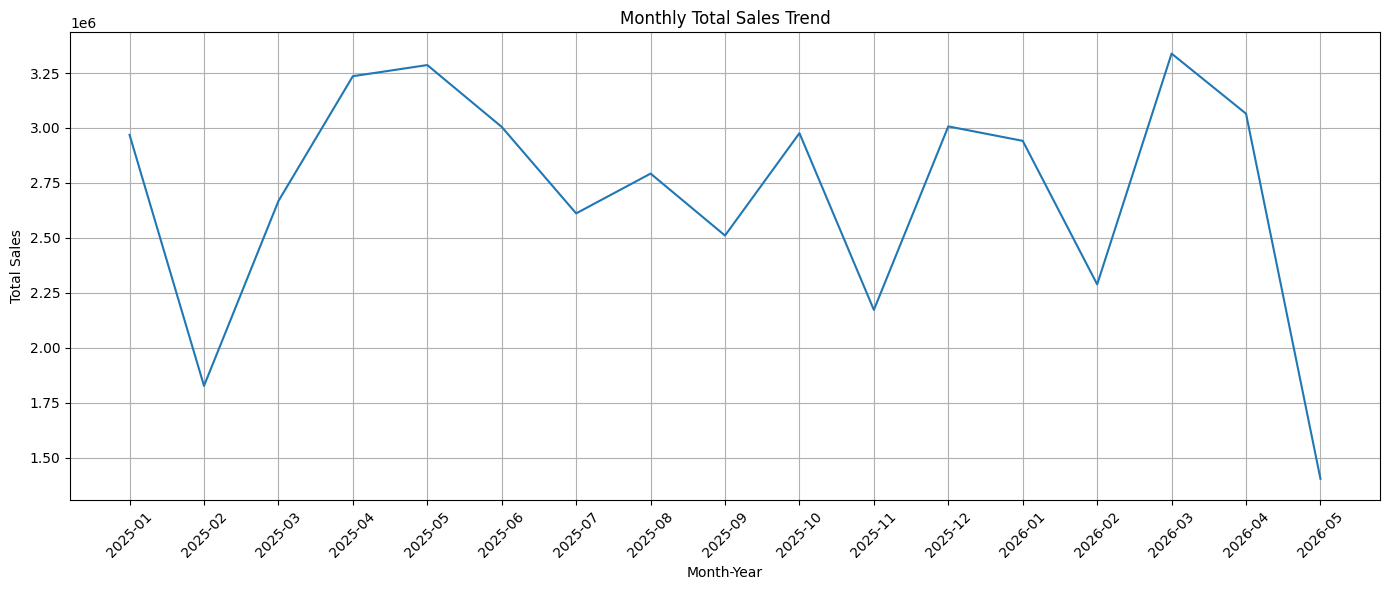


Total Sales by Medicine Type (Branded vs. Generic):


,Total_Sales
Medicine_Type,
Branded,30146639.08
Generic,15949228.14


/tmp/ipykernel_2436/359334365.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medicine_type_sales.index, y=medicine_type_sales.values, palette='viridis')


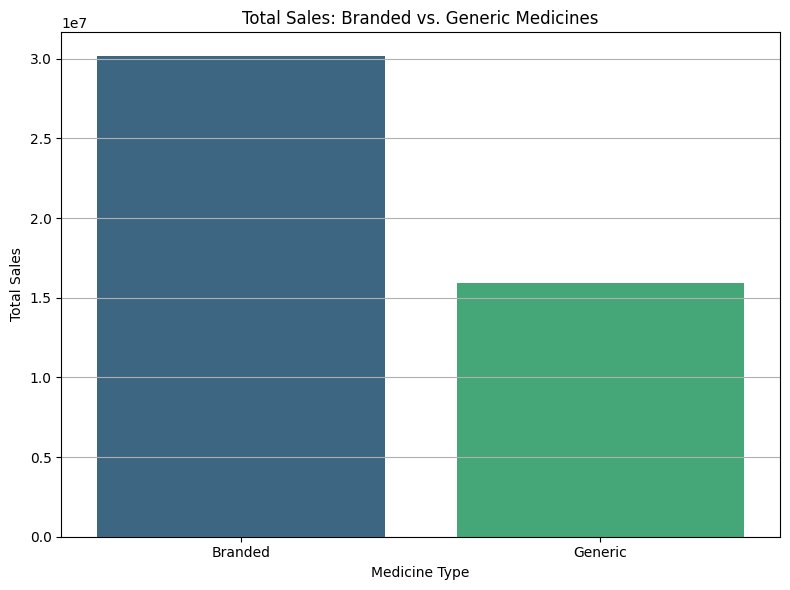

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize monthly sales growth
plt.figure(figsize=(14, 6))
sns.lineplot(x='Month_Year', y='Total_Sales', data=monthly_sales)
plt.title('Monthly Total Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare branded versus generic medicines
medicine_type_sales = pharma_df.groupby('Medicine_Type')['Total_Sales'].sum()

print("\nTotal Sales by Medicine Type (Branded vs. Generic):")
display(medicine_type_sales)

plt.figure(figsize=(8, 6))
sns.barplot(x=medicine_type_sales.index, y=medicine_type_sales.values, palette='viridis')
plt.title('Total Sales: Branded vs. Generic Medicines')
plt.xlabel('Medicine Type')
plt.ylabel('Total Sales')
plt.grid(axis='y')
plt.tight_layout()
plt.show()